In [1]:
import openbabel
from openbabel import pybel
import csv,sys
import pandas as pd
import numpy as np

In [2]:
SMARTS1=pd.read_csv('/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv') 

In [3]:
SMARTS1['SMARTS']

0                                           [F,Cl,Br,I]
1                                                   [F]
2                                                  [Cl]
3                                                  [Br]
4                                                   [I]
5                                           [CX3]=[OX1]
6                                     [#6][CX3](=O)[#6]
7                                       [CX3H1](=O)[#6]
8                                [NX3][CX3](=[OX1])[#6]
9                              [#6][CX3](=O)[OX2H0][#6]
10                                     [CX3](=O)[OX2H1]
11    [$([cX3](:*):*),$([cX2+](:*):*),$([CX3]=*),$([...
12                                         [$([CX2]#C)]
13                     [$([cX3](:*):*),$([cX2+](:*):*)]
14                                          [NX1]#[CX2]
15                                 [NX3;H2,H1;!$(NC=O)]
16              [$([NX3](=O)=O),$([NX3+](=O)[O-])][!#8]
17                                          [NX2

In [4]:
#load dataset 
xgb_d2 = pd.read_csv('fps_xgboost_esol_outliers2.csv')
rf_d2 = pd.read_csv('fps_rf_esol_outliers_n2.csv')

In [5]:
len(xgb_d2)

71

In [6]:
len(rf_d2)

75

In [7]:
#outputfile
Output="FG_esol_xgb_d2.csv"

#Functional Group names 
FG_names=SMARTS1['FG']

#Get SMART CODES 
SMARTS_codes=SMARTS1['SMARTS']

#Get SMILES
smiles=xgb_d2['SMILES']
xgb_d2=np.array(xgb_d2)
FG_list=[]

for f in range(len(xgb_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(xgb_d2[f][5])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES
    
#for each molecule
for f in range(len(xgb_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(xgb_d2[f][5])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES
    for g in SMARTS_codes:
        smarts = pybel.Smarts(g)
        if smarts.findall(mol) == []:
            FG.append("0")
        else:
            FG.append("1")
    FG_list.append(FG)

FG_names2=list(FG_names) 
FG_names2.insert(0,"StdInChIKey") 
FG_list=pd.DataFrame(data=FG_list,columns=FG_names2) 

#this can then be outputted/merged or graphed 
FG_list.to_csv(Output,index=False)    

In [8]:
FG_list

,StdInChIKey,Halides,F,Cl,Br,I,Carbonyl,Ketone,Aldehyde,Amide,...,Alcohol,Ether inc. ester,P,S,Thiol,Thioamide,Sulfonamide,H-bond donor,Acidic hydroxyl,H-bond acceptor
0,2.496825,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2.453112,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-2.243122,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,-2.357521,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,-2.419447,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,2.229631,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
67,3.050837,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
68,2.251040,0,0,0,0,0,1,0,0,1,...,0,1,0,0,0,0,0,0,0,1
69,2.898015,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1


In [9]:
FG_sum_xgb_d2 = FG_list.iloc[:,1:30].astype(int).sum()
FG_sum_xgb_d2_merge = (FG_sum_xgb_d2.to_frame('xgb_d2'))/len(xgb_d2)

In [10]:
#outputfile
Output="FG_esol_rf_d2.csv"

#Functional Group names 
FG_names=SMARTS1['FG']

#Get SMART CODES 
SMARTS_codes=SMARTS1['SMARTS']

#Get SMILES
smiles=rf_d2['SMILES']
rf_d2=np.array(rf_d2)
FG_list=[]

for f in range(len(rf_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(rf_d2[f][5])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES

#for each molecule
for f in range(len(rf_d2)):
    FG=[]
    #Get StdInChIKey identifier
    FG.append(rf_d2[f][5])
    #Create mol object from smiles
    mol=pybel.readstring("smi",smiles[f])
    #match all SMARTS to SMILES
    for g in SMARTS_codes:
        smarts = pybel.Smarts(g)
        if smarts.findall(mol) == []:
            FG.append("0")
        else:
            FG.append("1")
    FG_list.append(FG)

FG_names2=list(FG_names) 
FG_names2.insert(0,"StdInChIKey") 
FG_list=pd.DataFrame(data=FG_list,columns=FG_names2) 

#this can then be outputted/merged or graphed 
FG_list.to_csv(Output,index=False)

In [11]:
FG_list

,StdInChIKey,Halides,F,Cl,Br,I,Carbonyl,Ketone,Aldehyde,Amide,...,Alcohol,Ether inc. ester,P,S,Thiol,Thioamide,Sulfonamide,H-bond donor,Acidic hydroxyl,H-bond acceptor
0,Brc1cc(Br)cc(Br)c1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CC1CCCO1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,CCCCC(C)CC,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Clc1ccc(cc1)c2ccc(Cl)cc2,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,c1ccc2c(c1)c3cccc4c3c2cc5ccccc54,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,ClC(=C(Cl)C(=C(Cl)Cl)Cl)Cl,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71,CCC(C(CC)c1ccc(O)cc1)c2ccc(O)cc2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
72,ClC1C(Cl)C(Cl)C(Cl)C(Cl)C1Cl,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,COC(C)(C)CCCC(C)CC=CC(C)=CC(=O)OC(C)C,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [12]:
FG_sum_rf_d2 = FG_list.iloc[:,1:30].astype(int).sum()
FG_sum_rf_d2_merge = (FG_sum_rf_d2.to_frame('rf_d2'))/len(rf_d2)

In [13]:
FG_sum_rf_d2_merge 

,rf_d2
Halides,0.346667
F,0.093333
Cl,0.266667
Br,0.040000
I,0.000000
Carbonyl,0.240000
Ketone,0.013333
Aldehyde,0.000000
Amide,0.066667
Ester,0.133333


In [14]:
FG_sum_esol = pd.read_parquet('FG_sum_esol.parquet')

In [15]:
FG_sum_xgb_d2_merge ['rf_d2'] =  FG_sum_rf_d2_merge
FG_sum_xgb_d2_merge ['esol'] =  FG_sum_esol

In [16]:
FG_sum_xgb_d2_merge

,xgb_d2,rf_d2,esol
Halides,0.295775,0.346667,0.298951
F,0.056338,0.093333,0.041084
Cl,0.225352,0.266667,0.226399
Br,0.028169,0.040000,0.043706
I,0.000000,0.000000,0.013986
Carbonyl,0.239437,0.240000,0.351399
Ketone,0.056338,0.013333,0.075175
Aldehyde,0.014085,0.000000,0.014860
Amide,0.084507,0.066667,0.137238
Ester,0.056338,0.133333,0.086538


Text(0.5, 1.0, 'ESOL')

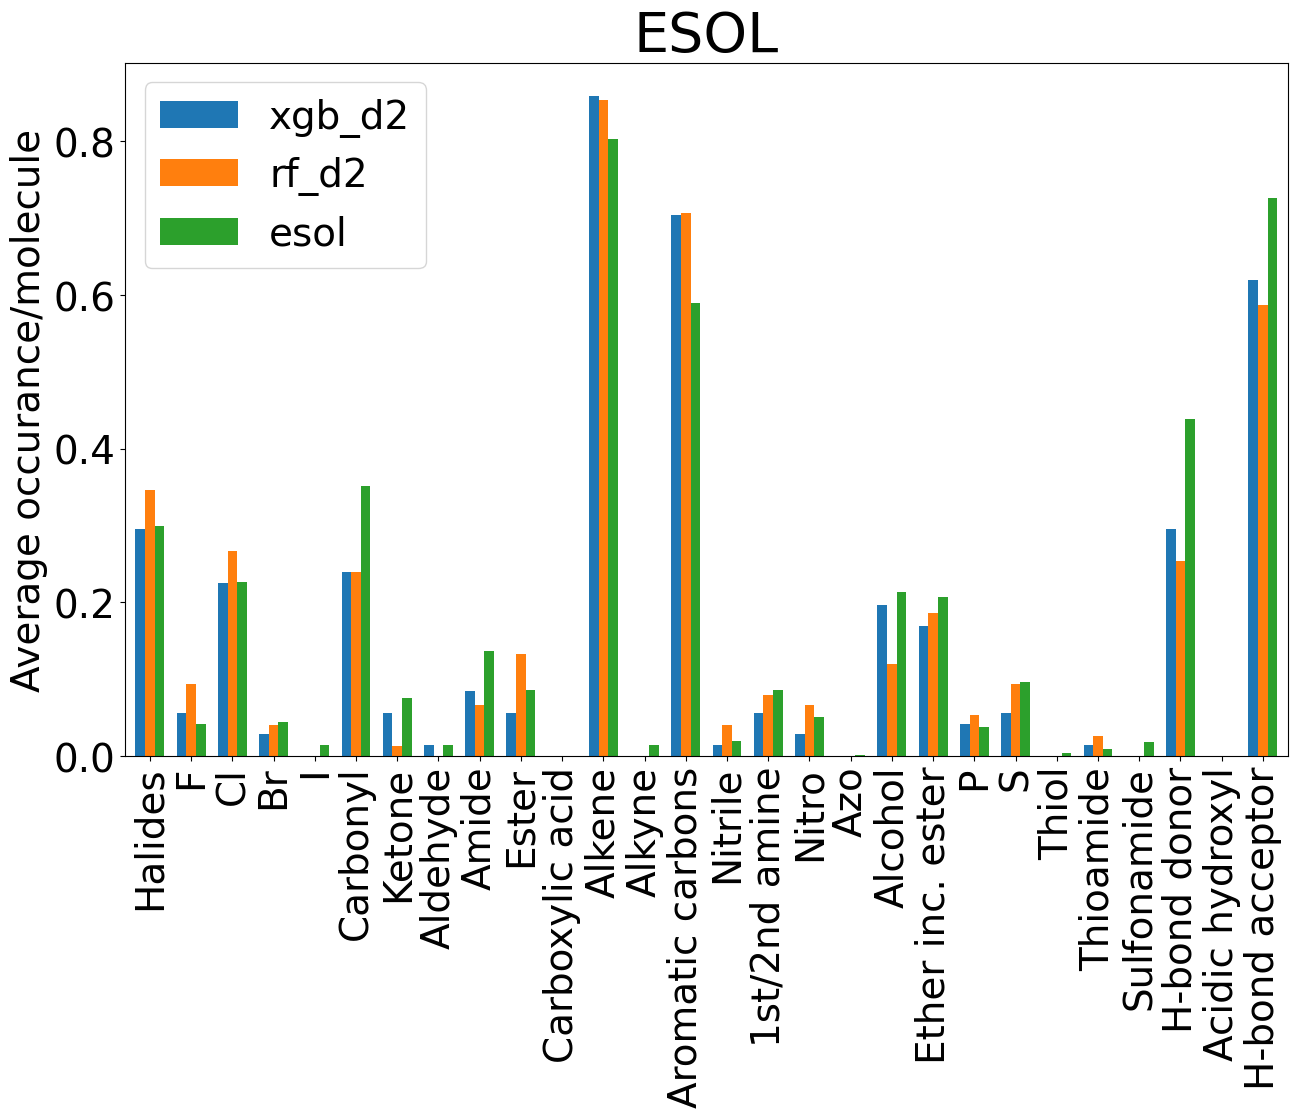

In [17]:
import matplotlib.pyplot as plt
# Set the default text font size
plt.rc('font', size=28)
ax=FG_sum_xgb_d2_merge.plot.bar(figsize=(15,9), width=0.7)
ax.set_ylabel("Average occurance/molecule", size=28)
ax.set_title("ESOL", size=40)

In [18]:
FG_sum_xgb_d2_merge['Random Forest'] = FG_sum_xgb_d2_merge['rf_d2'] - FG_sum_xgb_d2_merge['esol']
FG_sum_xgb_d2_merge['XGBoost'] = FG_sum_xgb_d2_merge['xgb_d2'] - FG_sum_xgb_d2_merge['esol']



In [19]:
FG_sum_xgb_d2_merge_change = FG_sum_xgb_d2_merge[['XGBoost', 'Random Forest']]

In [20]:
FG_sum_xgb_d2_merge_change

,XGBoost,Random Forest
Halides,-0.003176,0.047716
F,0.015254,0.052249
Cl,-0.001046,0.040268
Br,-0.015537,-0.003706
I,-0.013986,-0.013986
Carbonyl,-0.111962,-0.111399
Ketone,-0.018837,-0.061841
Aldehyde,-0.000776,-0.014860
Amide,-0.052731,-0.070571
Ester,-0.030200,0.046795


Text(0.5, 1.0, 'ESOL')

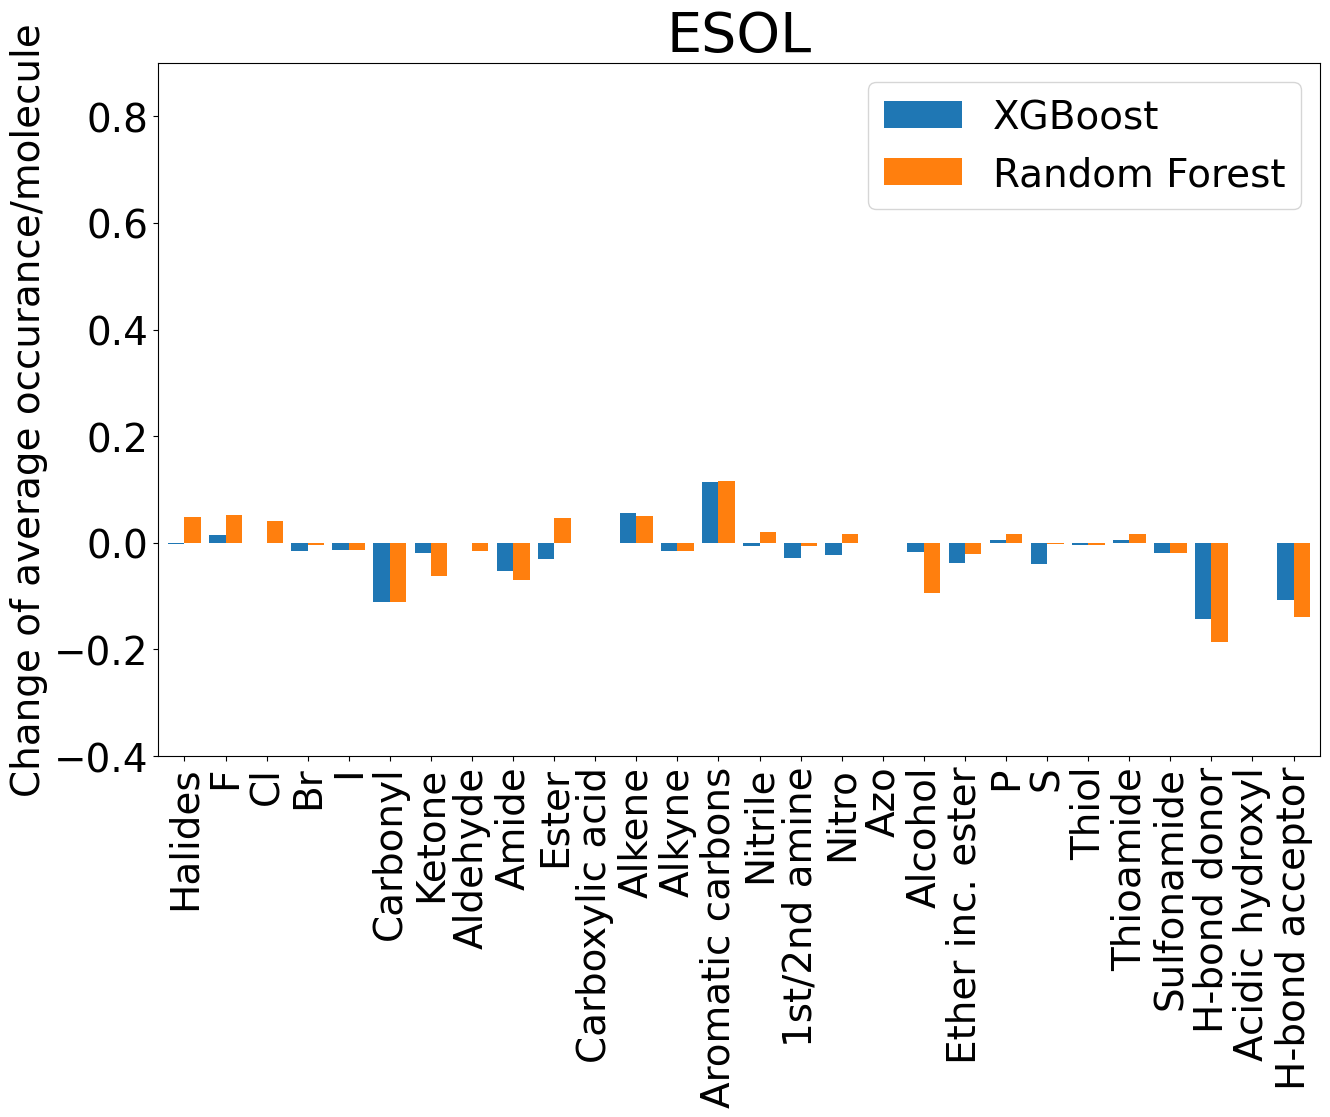

In [21]:
# Set the default text font size
plt.rc('font', size=28)
ax=FG_sum_xgb_d2_merge_change.plot.bar(figsize=(15,9), ylim=(-0.4, 0.9), width=0.8)
ax.set_ylabel("Change of average occurance/molecule", size=28)
ax.set_title("ESOL", size=40)